In [32]:
# Import librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

In [33]:
nov = pd.read_csv('./datasets/november.csv', parse_dates=['event_time'])
dec = pd.read_csv('./datasets/december.csv', parse_dates=['event_time'])

In [34]:
nov.head(3).T

,0,1,2
event_time,2019-11-01 00:00:14+00:00,2019-11-01 00:00:41+00:00,2019-11-01 00:01:04+00:00
event_type,cart,purchase,purchase
product_id,1005014,13200605,1005161
category_id,2053013555631882655,2053013557192163841,2053013555631882655
category_code,electronics.smartphone,furniture.bedroom.bed,electronics.smartphone
brand,samsung,NaN,xiaomi
price,503.09,566.3,211.92
user_id,533326659,559368633,513351129
user_session,6b928be2-2bce-4640-8296-0efdf2fda22a,d6034fa2-41fb-4ac0-9051-55ea9fc9147a,e6b7ce9b-1938-4e20-976c-8b4163aea11d


In [35]:
dec.head(3).T

,0,1,2
event_time,2019-12-01 00:00:02+00:00,2019-12-01 00:00:12+00:00,2019-12-01 00:00:28+00:00
event_type,purchase,cart,cart
product_id,26400248,1004833,17800342
category_id,2053013553056579841,2232732093077520756,2053013559868129947
category_code,computers.peripherals.printer,construction.tools.light,computers.desktop
brand,NaN,samsung,zeta
price,132.31,167.03,66.9
user_id,535135317,557794415,550465671
user_session,61792a26-672f-4e61-9832-7b63bb1714db,6fecf566-ebb0-4e70-a243-cdc13ce044cb,22650a62-2d9c-4151-9f41-2674ec6d32d5


In [36]:
print(f'November data shape: {nov.shape}')
print(f'December data shape: {dec.shape}')

November data shape: (2885158, 9)
December data shape: (4147967, 9)


In [37]:
# Combine the 2 datasets
data = pd.concat([nov, dec])
data.tail(3).T

,4147964,4147965,4147966
event_time,2019-12-31 23:58:28+00:00,2019-12-31 23:58:40+00:00,2019-12-31 23:59:09+00:00
event_type,cart,cart,cart
product_id,1005169,1004961,1004903
category_id,2232732093077520756,2232732093077520756,2232732093077520756
category_code,construction.tools.light,construction.tools.light,construction.tools.light
brand,samsung,oppo,huawei
price,190.25,154.35,76.94
user_id,592177750,518939164,595414329
user_session,d165dbb1-ba94-47cc-a4c8-58bfc1558264,5e937c29-c53d-4c57-92de-09ba1e2a8a9a,999eece3-9895-4dc0-9ad0-16547e8aa6cd


In [38]:
# Verify the shape of the combined dataset
print(f'data shape: {data.shape}')

data shape: (7033125, 9)


In [39]:
# Sanity check
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 7033125 entries, 0 to 4147966
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype              
---  ------         --------------    -----              
 0   event_time     7033125 non-null  datetime64[ns, UTC]
 1   event_type     7033125 non-null  object             
 2   product_id     7033125 non-null  int64              
 3   category_id    7033125 non-null  int64              
 4   category_code  7033125 non-null  object             
 5   brand          6638017 non-null  object             
 6   price          7033125 non-null  float64            
 7   user_id        7033125 non-null  int64              
 8   user_session   7033098 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 536.6+ MB


> We have missing values in `brand` which is normal,
> And a few ones in `user_session` 

In [40]:
# Validating the assumption that the data is from november to december
data['event_time'].min(), data['event_time'].max()


(Timestamp('2019-11-01 00:00:14+0000', tz='UTC'),
 Timestamp('2019-12-31 23:59:09+0000', tz='UTC'))

In [41]:
# Check the number of unique days with transactions per month
data.assign(date=data['event_time'].dt.date,
                   month=data['event_time'].dt.month)\
                    .groupby('month')['date'].nunique()\
         .reset_index(name='days_with_transactions')

,month,days_with_transactions
0,11,30
1,12,31


> Nice! Every day is filled, which means we have at least one even for each day during the period.

### Data understanding: 
#### Understand each variable

##### Validating assumptions in the data

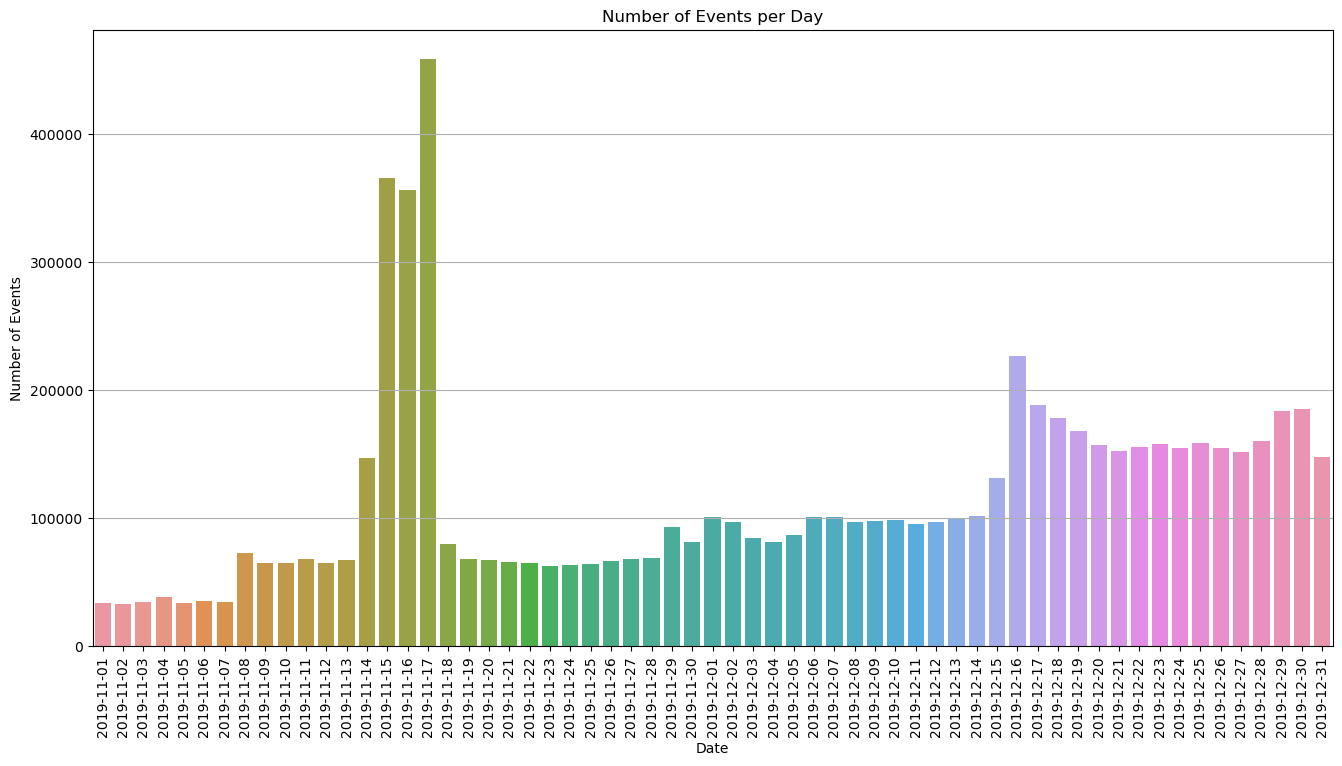

In [42]:
# Chart showing the number of events per day
daily_counts = data.groupby(data['event_time'].dt.date).size().reset_index(name='event_count')

plt.figure(figsize=(16, 8))
sns.barplot(x='event_time', y='event_count', data=daily_counts)
plt.xticks(rotation=90)
plt.title('Number of Events per Day')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.grid(axis='y')
plt.show()

In [43]:
# Check the value counts of event types
repartition = data['event_type'].value_counts(normalize=True) * 100
print(repartition)

event_type
cart        75.021729
purchase    24.978271
Name: proportion, dtype: float64


> Seem normal for an e-commerce environment

##### Variable `price`

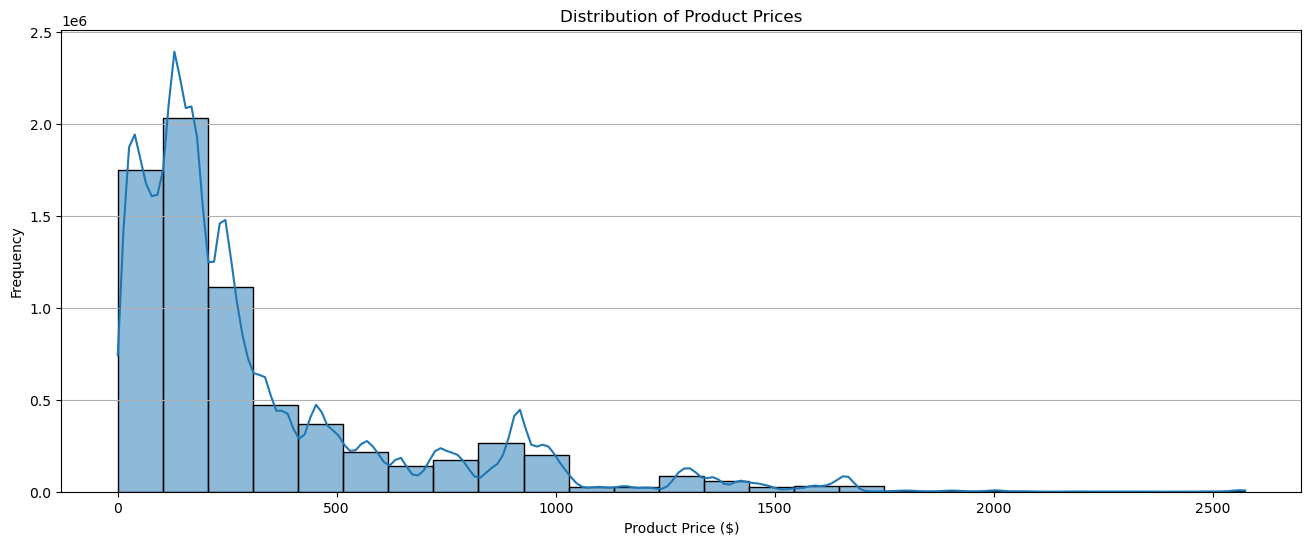

In [44]:
# Visualize the price distribution
plt.figure(figsize=(16, 6))
sns.histplot(data['price'], bins=25, kde=True)
plt.title('Distribution of Product Prices')
plt.xlabel('Product Price ($)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

> Comment:\
Most of our products are listed or sold under $500, with some outlier up to $2,500

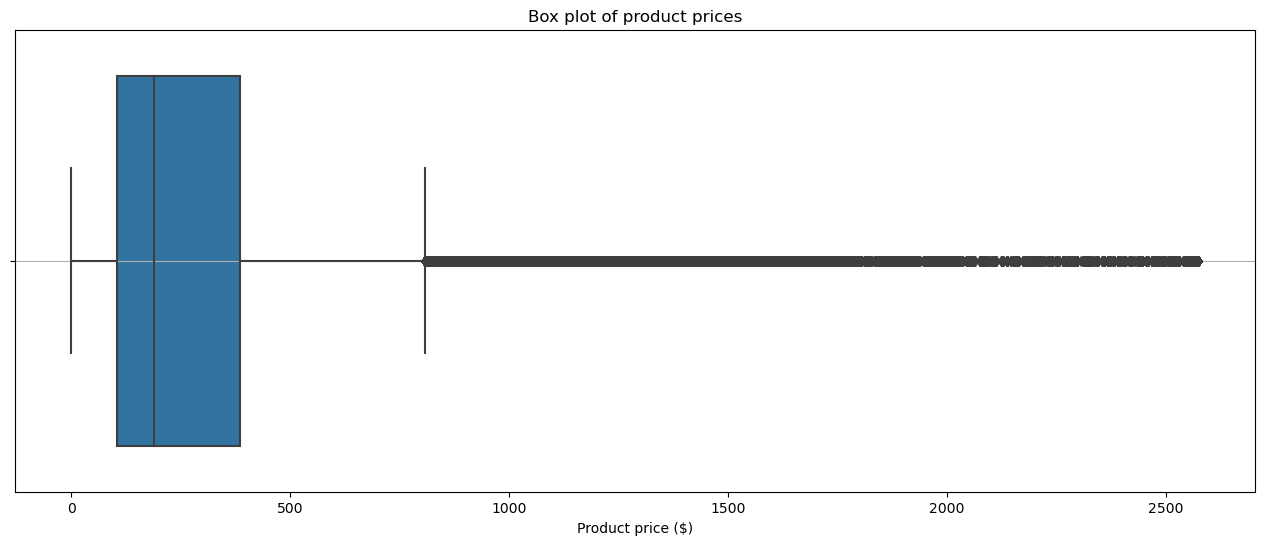

In [45]:
# Visualize the distribution in a box plot
plt.figure(figsize=(16, 6))
sns.boxplot(x='price', data=data)
plt.title('Box plot of product prices')
plt.xlabel('Product price ($)')
plt.grid(axis='y')
plt.show()

> We can see that there are some outliers with very high prices.

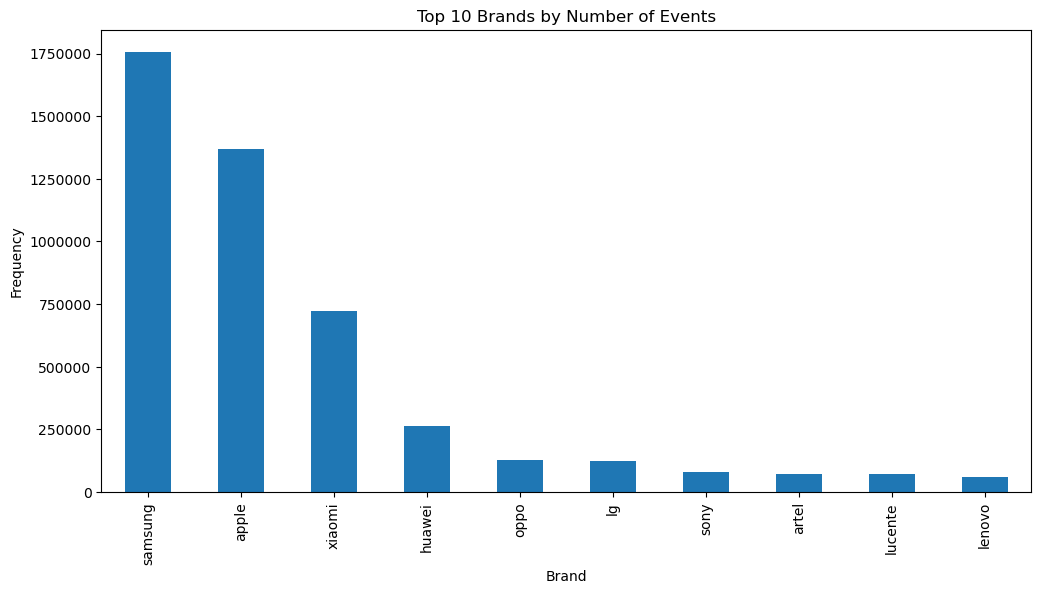

In [46]:
# Distribution of brands
plt.figure(figsize=(12, 6))
data['brand'].value_counts().head(10).plot(kind='bar', title='Top 10 Brands by Number of Events')
plt.xlabel('Brand')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='y') 

plt.show()

##### Investigate consistency of product categories

In [47]:
# Check if our products are correctly categorized
data.groupby('product_id')['category_code'].nunique().reset_index(name='num_categories')\
    .query('num_categories > 1')


,product_id,num_categories
1,1000978,2
2,1001588,2
5,1001618,2
6,1001619,2
8,1002098,2
...,...,...
77870,100026889,2
77911,100027045,2
77968,100027452,2
77989,100027645,2


> Almost 13,000 products are assigned to multiple categories. \
This suggests there is an error somewhere in our underlying product catalog.

In [48]:
# Top 1o categories by number of events
data['category_code'].value_counts().reset_index(name='event_count').head(10)

,category_code,event_count
0,construction.tools.light,1823398
1,electronics.smartphone,1577185
2,electronics.audio.headphone,240308
3,electronics.clocks,233198
4,sport.bicycle,231644
5,apparel.shoes,212586
6,appliances.kitchen.refrigerators,190523
7,appliances.personal.massager,185601
8,appliances.environment.vacuum,170290
9,appliances.kitchen.washer,170121


> The categories `construction.tools.light`	and	`electronics.smartphone` categorize most of the products.

In [49]:
# Observe the top 10 of brands in the category 'construction.tools.light'

category_brands = data[data['category_code'] == 'construction.tools.light']\
                    ['brand'].value_counts().reset_index(name='event_count').head(10)

category_brands

,brand,event_count
0,samsung,727599
1,apple,521481
2,xiaomi,304546
3,huawei,149347
4,oppo,68446
5,vivo,10709
6,meizu,9093
7,honor,4389
8,nokia,3231
9,omron,3003


> Is curious to see numerous construction tools into technology manufacturers

In [50]:
# Look at the products that have multiple codes against them
multi_product_ids = data.groupby('product_id')['category_code']\
    .nunique().loc[lambda x: x > 1].index.values
multi_product_ids[0:10]

array([1000978, 1001588, 1001618, 1001619, 1002098, 1002100, 1002101,
       1002225, 1002367, 1002482], dtype=int64)

In [51]:
# See some of these products and its category codes
data.loc[data['product_id'].isin(multi_product_ids[0:3]), ['product_id', 'category_code']]\
    .value_counts().reset_index(name='category_count').sort_values('product_id')

,product_id,category_code,category_count
1,1000978,electronics.smartphone,80
2,1000978,appliances.kitchen.refrigerators,74
3,1001588,construction.tools.light,50
5,1001588,electronics.smartphone,22
0,1001618,electronics.smartphone,105
4,1001618,construction.tools.light,24


> We have the inconsistent mixes of same product in different categories 

##### Investigate consistencies in data categories

Since most brands originate from the smartphone category, we identified cases where products are assigned to \
multiple categories. The category `construction.tools.light` exhibits inconsistencies, as many products \
assigned to it are not logically belong there. Consequently, when a product is classified under both construction.tools.light and another category, we prioritize the alternative category and exclude construction.tools.light.\
For other products in the others duplicate categories, remain the most frequent.

In [52]:
# Function to get the correct category for a product_id

def get_correct_category(product_id_rows):
    categories = product_id_rows['category_code'].value_counts()

    # fixing `construction.tools.light` misclassification
    if 'construction.tools.light' in categories.index:
        return categories.index.drop('construction.tools.light').values[0]
    else:
        # Return the most frequent category for other cathegories different than 'construction.tools.light'
        return categories.index[0]
    
corrected_categories = (
    data[data['product_id'].isin(multi_product_ids)]
    .groupby('product_id')
    .apply(get_correct_category)
    .reset_index(name='corrected_category')
)

corrected_categories


,product_id,corrected_category
0,1000978,electronics.smartphone
1,1001588,electronics.smartphone
2,1001618,electronics.smartphone
3,1001619,electronics.smartphone
4,1002098,electronics.smartphone
...,...,...
12879,100026889,apparel.shoes
12880,100027045,apparel.shoes.sandals
12881,100027452,appliances.kitchen.refrigerators
12882,100027645,appliances.kitchen.hood


In [53]:
# merging the corrected categories back to the main data
data = data.merge(corrected_categories, on='product_id', how='left')

In [54]:
# Replace the category_code with corrected_category where applicable
data['category_code'] = np.where(data['corrected_category'].notnull(),
                                  data['corrected_category'],
                                  data['category_code'])

data['category_code'].value_counts()

category_code
electronics.smartphone              3350680
sport.bicycle                        384120
appliances.personal.massager         254300
electronics.clocks                   228546
appliances.kitchen.refrigerators     214637
                                     ...   
apparel.skirt                           261
construction.tools.soldering            200
sport.diving                            144
computers.components.sound_card         118
auto.accessories.light                   41
Name: count, Length: 134, dtype: int64

> Now our data mostly consist of smartphones.

In [55]:
# Extract the first level category for observation
data['main_category'] = data['category_code'].str.split('.').str[0]
data = data.rename(columns={'category_code': 'subcategory'})

data['main_category'].value_counts()

main_category
electronics     3908916
appliances      1250149
apparel          540955
sport            439029
computers        291790
furniture        216264
construction     144637
kids              98236
auto              89079
accessories       39350
country_yard       6106
medicine           5616
stationery         2998
Name: count, dtype: int64

> This may confirm our assumption made in the previous traitment about `construction.tools.light` because even here most of the products come from smartphones.

##### Investigate the consistencies of brand labels

In [56]:
# Check whether a product_id maps to multiple brands
duplicate_brands = data.assign(brand = data['brand'].fillna('No Brand'))\
    .groupby('product_id')['brand'].nunique().reset_index(name='num_brands')\
    .query('num_brands > 1')

duplicate_brands

,product_id,num_brands
5,1001618,2
14,1002310,2
45,1002786,2
51,1002877,2
75,1003080,2
...,...,...
83798,100062901,2
83803,100063013,2
83807,100063159,2
83808,100063161,2


In [57]:
# Function to get the correct brand for a product_id

def get_correct_brand(product_id_rows):
    brands = product_id_rows['brand'].value_counts(dropna=False)

    if isinstance(brands.index[0], str):
        return brands.index[0]
    
    if len(brands) == 1:
        return np.nan
    
    return brands.index[1]

corrected_brands = (
    data[data['product_id'].isin(duplicate_brands['product_id'])]
    .groupby('product_id')
    .apply(get_correct_brand)
    .reset_index(name='corrected_brand')
)

corrected_brands


,product_id,corrected_brand
0,1001618,apple
1,1002310,lg
2,1002786,apple
3,1002877,samsung
4,1003080,huawei
...,...,...
1240,100062901,sokolov
1241,100063013,xiaomi
1242,100063159,akku
1243,100063161,asus


In [58]:
# Merge the corrected brands back to the main data
data = data.merge(corrected_brands, on='product_id', how='left')

In [59]:
# Replace the brand with corrected_brand where applicable
data['brand'] = np.where(data['corrected_brand'].notnull(),
                         data['corrected_brand'],
                         data['brand'])

data['brand'].value_counts()

brand
samsung          1756420
apple            1368510
xiaomi            719910
huawei            263429
oppo              128661
                  ...   
tehnopark              1
blenderbottle          1
provoc                 1
annalafarg             1
usmedica               1
Name: count, Length: 3339, dtype: int64

In [ ]:
# Sanity check to ensure each product_id maps to a unique (main_category, subcategory, brand) combination
assert (len(data[['product_id', 'main_category', 'subcategory', 'brand']]
            .drop_duplicates()) == data['product_id'].nunique())

In [62]:
# Creating a combined column as a unique identifier
data['product_identifier'] = (data['product_id'].astype(str) + '-' +
                              data['brand'] + ' ' +
                              data['subcategory'])

data.head()

,event_time,event_type,product_id,category_id,subcategory,brand,price,user_id,user_session,corrected_category,main_category,corrected_brand,product_identifier
0,2019-11-01 00:00:14+00:00,cart,1005014,2053013555631882655,electronics.smartphone,samsung,503.09,533326659,6b928be2-2bce-4640-8296-0efdf2fda22a,electronics.smartphone,electronics,NaN,1005014-samsung electronics.smartphone
1,2019-11-01 00:00:41+00:00,purchase,13200605,2053013557192163841,furniture.bedroom.bed,NaN,566.30,559368633,d6034fa2-41fb-4ac0-9051-55ea9fc9147a,NaN,furniture,NaN,NaN
2,2019-11-01 00:01:04+00:00,purchase,1005161,2053013555631882655,electronics.smartphone,xiaomi,211.92,513351129,e6b7ce9b-1938-4e20-976c-8b4163aea11d,electronics.smartphone,electronics,NaN,1005161-xiaomi electronics.smartphone
3,2019-11-01 00:03:24+00:00,cart,1801881,2053013554415534427,appliances.personal.massager,samsung,488.80,557746614,4d76d6d3-fff5-4880-8327-e9e57b618e0e,appliances.personal.massager,appliances,NaN,1801881-samsung appliances.personal.massager
4,2019-11-01 00:03:39+00:00,cart,1005115,2053013555631882655,electronics.smartphone,apple,949.47,565865924,fd4bd6d4-bd14-4fdc-9aff-bd41a594f82e,electronics.smartphone,electronics,NaN,1005115-apple electronics.smartphone


In [ ]:
data.drop(columns=['corrected_category', 'corrected_brand'], inplace=True)

In [ ]:
data.rename(columns={'main_category': 'category'}, inplace=True)

In [67]:
# reorder columns
cols = ['event_time', 'event_type', 'product_id', 'brand', 'subcategory', 
        'category','product_identifier', 'price']
data = data[cols]

In [68]:
# Export the cleaned data
data.to_parquet('./datasets/evnts.parquet.gz', compression='gzip')